# Exploratory Synthetic Data Analysis

## Health Report for synthetic attacks Dataset

In [7]:
import pandas as pd
from ai_waf_v2.data import WafDataset

#### Inspection of parquet file

In [ ]:
# Base splits from public datasets (deduped)
#df = pd.read_parquet("../data/splits_pre_aug/train.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/val.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/test.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/adversarial.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/canary.parquet")
# Attack payloads only (Grammar + LLM)
df = pd.read_parquet("../data/augmented/synthesis/synthesized_attacks.parquet")
# Attack payloads and innocent payloads wrapped inside requests
#df = pd.read_parquet("../data/augmented/framed/framed_records.parquet")
# Final augmented splits
#df = pd.read_parquet("../data/splits/train.parquet")
#df = pd.read_parquet("../data/splits/val.parquet")
#df = pd.read_parquet("../data/splits/test.parquet")
#df = pd.read_parquet("../data/splits/adversarial.parquet")
#df = pd.read_parquet("../data/splits/canary.parquet")

print(f"--- Augmented Dataset ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

print("\n--- Unique Raw ---")
print(df['raw'].nunique())


--- Augmented Dataset ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
39506

--- Unique Categories ---
['xxe' 'header_injection' 'ssti' 'ssrf' 'xss' 'lfi' 'cmdi'
 'path_traversal']

--- Unique Labels ---
[1]

--- Distribution (Counts) ---
       attack_class  label  count
0              cmdi      1   4911
1  header_injection      1   5000
2               lfi      1   5000
3    path_traversal      1   5000
4              ssrf      1   5000
5              ssti      1   5000
6               xss      1   4595
7               xxe      1   5000


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
35736,e6576e73-1742-4d33-94c7-368efb4dc31a,GET,/download,file=%2e%2E/..%252F..%252FeTc%252FPaSsWD,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",,GET /download?file=%2e%2E/..%252F..%252FeTc%252FPaSsWD HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n,1,path_traversal,aug_synthesis_path_traversal,
33930,a5f6989b-70de-4907-83c9-698bcf5a1b29,POST,/api/v1/ping,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",host=%50x42%22%27%24%70x420x490x460x53%70x44%30x42%24%70x420x490x460x53%70x440x690x64%22%20x43,POST /api/v1/ping HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\nhost=%50x42%22%27%24%70x420x490x460x53%70x44%30x42%24%70x420x490x460x53%70x440x690x64%22%20x43,1,cmdi,aug_synthesis_cmdi,
22335,6006f6c3-4df7-45db-8d36-7ef434ff1f5d,POST,/api/v1/comment,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}","msg=""'\' \u006f\u006e\u006c\u006f\u0061\u0064='\u0061\u006c\u0065\u0072\u0074(\u0064\u006f\u0063\u0075\u006d\u0065\u006e\u0074.\u0064\u006f\u006d\u0061\u0069\u006e)//'>',"",","POST /api/v1/comment HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\nmsg=""'\' \u006f\u006e\u006c\u006f\u0061\u0064='\u0061\u006c\u0065\u0072\u0074(\u0064\u006f\u0063\u0075\u006d\u0065\u006e\u0074.\u0064\u006f\u006d\u0061\u0069\u006e)//'>',"",",1,xss,aug_synthesis_xss,
21527,f571d92a-c188-47a2-bfea-7ec235dd3243,POST,/api/v1/comment,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",msg='><Svg onload=alert(1)>/>,POST /api/v1/comment HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\nmsg='><Svg onload=alert(1)>/>,1,xss,aug_synthesis_xss,
32486,827994f9-3c68-4adc-87a8-0834eb339199,POST,/api/v1/ping,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}","host=""'\u006c\u0073${\u0049\u0046\u0053}-\u006c\u0061\u0052${\u0049\u0046\u0053}/';${\u0049\u0046\u0053}\u0065\u0078\u0070\u006f\u0072\u0074${\u0049\u0046\u0053}\u0050\u0041\u0054\u0048=$\u0048\u004f\u004d\u0045/\u0062\u0069\u006e:$\u0050\u0041\u0054\u0048"",","POST /api/v1/ping HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\nhost=""'\u006c\u0073${\u0049\u0046\u0053}-\u006c\u0061\u0052${\u0049\u0046\u0053}/';${\u0049\u0046\u0053}\u0065\u0078\u0070\u006f\u0072\u0074${\u0049\u0046\u0053}\u0050\u0041\u0054\u0048=$\u0048\u004f\u004d\u0045/\u0062\u0069\u006e:$\u0050\u0041\u0054\u0048"",",1,cmdi,aug_synthesis_cmdi,



--- Unique Raw ---
34219


#### Check Label and Category Ratios

This identifies if your dataset is imbalanced. In WAF research, an **extreme imbalance** (e.g., 99% benign) requires specific handling during training.

In [10]:

# 1. Binary Label Distribution (0 vs 1)
print("--- Binary Label Counts ---")
print(df['label'].value_counts())
print("\n--- Binary Label Ratios ---")
print(df['label'].value_counts(normalize=True))

# 2. Specific Attack Category Distribution
print("\n--- Attack Category Counts ---")
print(df['attack_class'].value_counts())
print("\n--- Attack Category Ratios ---")
print(df['attack_class'].value_counts(normalize=True))


--- Binary Label Counts ---
label
1    39506
Name: count, dtype: int64

--- Binary Label Ratios ---
label
1    1.0
Name: proportion, dtype: float64

--- Attack Category Counts ---
attack_class
xxe                 5000
header_injection    5000
ssti                5000
ssrf                5000
lfi                 5000
path_traversal      5000
cmdi                4911
xss                 4595
Name: count, dtype: int64

--- Attack Category Ratios ---
attack_class
xxe                 0.126563
header_injection    0.126563
ssti                0.126563
ssrf                0.126563
lfi                 0.126563
path_traversal      0.126563
cmdi                0.124310
xss                 0.116311
Name: proportion, dtype: float64


#### Cross-Tabulate Label vs. Category

It is a good practice to verify that the label (0 or 1) correctly aligns with the category. This ensures that all categories labeled as "Normal" are actually 0.

In [ ]:
# Create a cross-tabulation table
ctab = pd.crosstab(df['attack_class'], df['label'])
print("--- Label Alignment Check ---")
print(ctab)

--- Label Alignment Check ---
label                             000 - Normal  126 - Path Traversal  \
category                                                               
Injection                                    0                     0   
Manipulation                                 0                  1806   
Normal                                    5796                     0   
Scanning for Vulnerable Software             0                     0   

label                             242 - Code Injection  \
category                                                 
Injection                                            1   
Manipulation                                         0   
Normal                                               0   
Scanning for Vulnerable Software                     0   

label                             272 - Protocol Manipulation  \
category                                                        
Injection                                                 

#### Visualizing with a Bar Chart

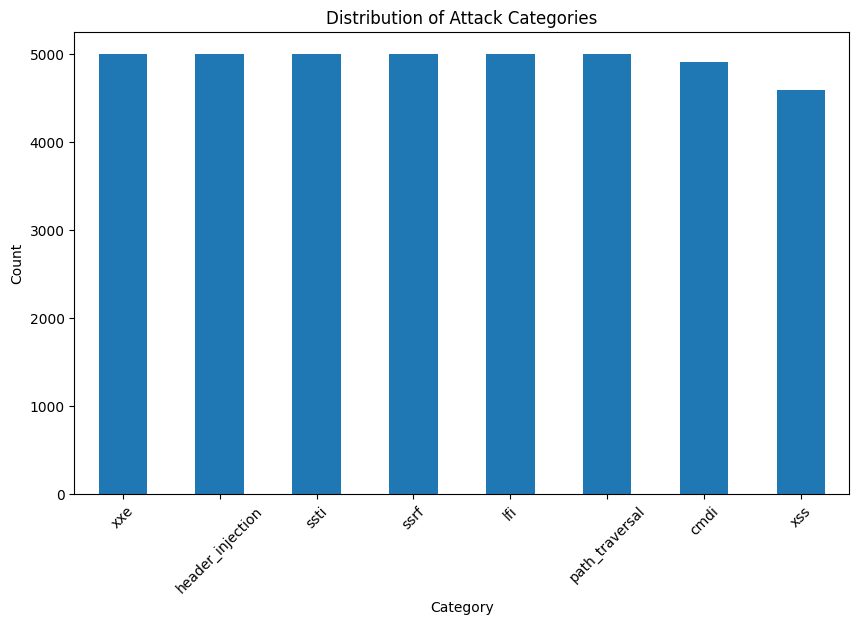

In [11]:
import matplotlib.pyplot as plt

# Plotting the categories
plt.figure(figsize=(10, 6))
df['attack_class'].value_counts().plot(kind='bar')
plt.title('Distribution of Attack Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Payload Length Analysis

Since we are using LLMs/SMLs, the length of the text field matters. If payloads are extremely long, they will be truncated, potentially losing the malicious part of the string.

In [12]:
# Add a length column for analysis
df['payload_len'] = df['raw'].str.len()

print("--- Payload Length Statistics ---")
print(df.groupby('attack_class')['payload_len'].describe())

# Check for empty payloads
print(f"\nEmpty payloads: {df['raw'].isna().sum()}")

--- Payload Length Statistics ---
                   count        mean         std   min    25%    50%    75%  \
attack_class                                                                  
cmdi              4911.0  232.002240  303.401573  76.0  115.0  156.0  238.0   
header_injection  5000.0  218.644400  158.007380  85.0  135.0  182.0  247.0   
lfi               5000.0  240.702400  291.779093  77.0  126.0  168.0  257.0   
path_traversal    5000.0  165.157000  164.633186  70.0  102.0  128.0  170.0   
ssrf              5000.0  188.581800  144.935687  83.0  113.0  143.0  210.0   
ssti              5000.0  190.139800  153.234772  83.0  109.0  146.0  220.0   
xss               4595.0  252.724701  272.263912  80.0  135.5  185.0  271.0   
xxe               5000.0  361.112600  240.041220  72.0  190.0  306.0  468.0   

                     max  
attack_class              
cmdi              6177.0  
header_injection  5903.0  
lfi               6877.0  
path_traversal    4313.0  
ssrf         